**Import Libraries**

Loaded all the necessary tools for data manipulation, visualization, machine learning, and model interpretation.

**Load Data**

Read the dataset from a file.

Removed unnecessary identifier columns.

Converted the target column (diagnosis) into binary values for Malignant and Benign.

**Basic Descriptive Statistics**

Examined general statistics of each feature (mean, standard deviation, min, max, etc.).

Counted the number of samples in each diagnosis category.

Check Missing Values & Duplicates

Checked for missing data in any feature.

Counted duplicated rows to ensure data quality.

**Visualize Diagnosis Distribution**

Plotted the number of samples in each class.

Created a percentage chart to see the class distribution clearly.

**Correlation Analysis**

Calculated correlations between features and the target.

Visualized the correlation matrix to identify relationships between features.

Identified the top features most correlated with the target.

**Detect Outliers**

Used visual plots to check for outliers in each feature.

This helps understand the range and distribution of feature values.

**Feature Engineering (Optional)**

Created new features by combining existing ones, such as multiplying or dividing two features.

These new features may provide additional predictive power.

**Split Features & Target**

Separated the input features from the target variable.

Split the dataset into training and testing sets while maintaining class balance.

**Feature Scaling (Optional)**

Normalized feature values to make them comparable in scale.

Useful for certain machine learning models.

**Train Model**

Built a predictive model using the training data.

Configured model parameters such as learning rate, depth, and number of iterations.

**Predictions & Evaluation**

Predicted the target values for the test set.

Calculated accuracy and generated a detailed classification report including precision, recall, and F1-score.

**Confusion Matrix**

Visualized true positives, true negatives, false positives, and false negatives to understand prediction errors.

***Feature Importance***

Identified which features had the greatest impact on the model’s predictions.

Plotted feature importance and highlighted the most influential feature.

Compared the distribution of this feature between classes.

Pairplot of Top Features

Visualized relationships among the top features correlated with the target.

Helped to see how well classes are separated based on these features.

**Cross-Validation**

Evaluated model stability using multiple subsets of the data.

Calculated mean accuracy across folds.

**ROC Curve & AUC**

Assessed the model’s ability to distinguish between classes.

Plotted the ROC curve and calculated the Area Under the Curve for performance measurement.

**SHAP Analysis for Feature Impact**

Explained model predictions by measuring each feature’s contribution.

Visualized which features had the most positive or negative impact on predictions.





In [34]:
!pip install catboost
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from catboost import CatBoostClassifier
import shap

In [35]:
df = pd.read_csv("/content/breast-cancer.csv")

In [36]:
# Drop ID column as it's not useful
df = df.drop("id", axis=1)

# Map diagnosis to binary values: M=1, B=0
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

In [37]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
diagnosis,569.0,0.372583,0.483918,0.000000,0.000000,0.000000,1.000000,1.00000
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400


In [38]:
 df["diagnosis"].value_counts()

,count
diagnosis,
0,357
1,212


In [39]:
 df.isnull().sum()

,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


In [40]:
df.duplicated().sum()

np.int64(0)

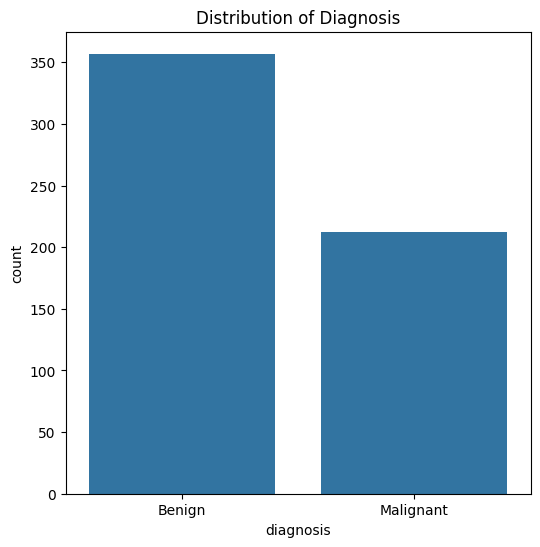

In [41]:
plt.figure(figsize=(6,6))
sns.countplot(x="diagnosis", data=df)
plt.xticks([0,1], ["Benign", "Malignant"])
plt.title("Distribution of Diagnosis")
plt.show()

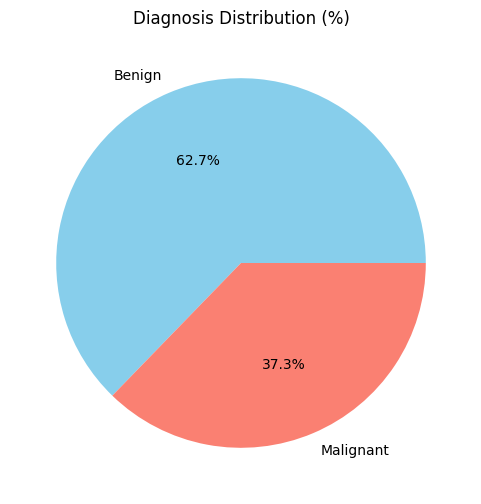

In [42]:
class_counts = df['diagnosis'].value_counts(normalize=True) * 100
plt.figure(figsize=(6,6))
plt.pie(class_counts, labels=["Benign", "Malignant"], autopct='%1.1f%%', colors=['skyblue','salmon'])
plt.title("Diagnosis Distribution (%)")
plt.show()


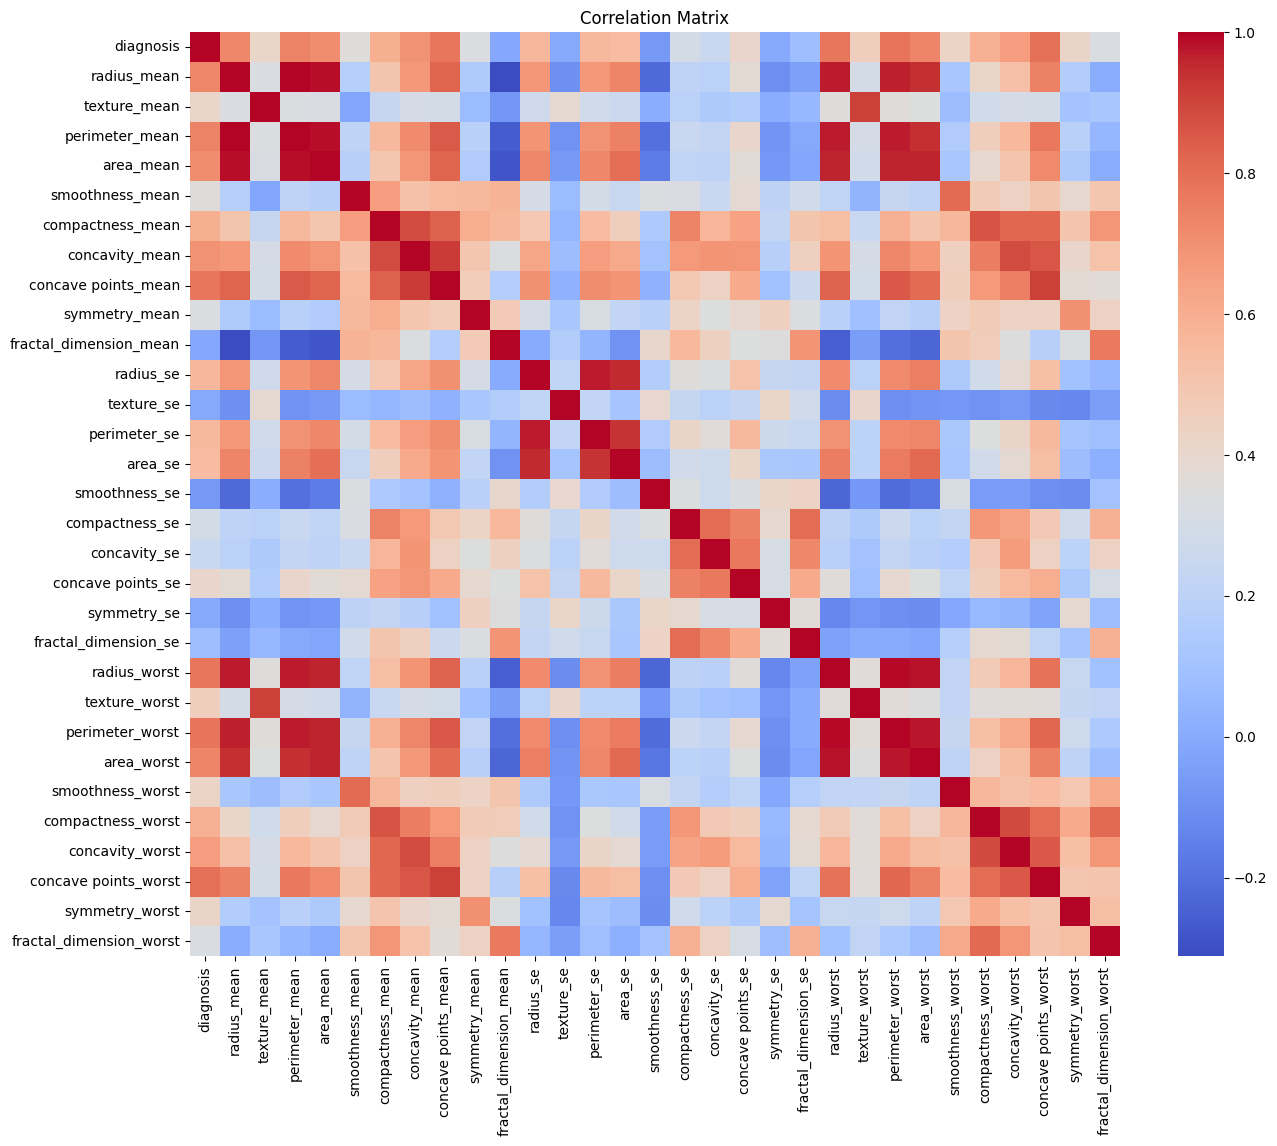

In [43]:
plt.figure(figsize=(15,12))
corr = df.corr()
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [44]:
# Show top 10 features correlated with target
corr_target = df.corr()['diagnosis'].sort_values(ascending=False)
print("\n✅ Top 10 Features Correlated with Diagnosis:\n", corr_target[1:11])


✅ Top 10 Features Correlated with Diagnosis:
 concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
concavity_worst         0.659610
Name: diagnosis, dtype: float64


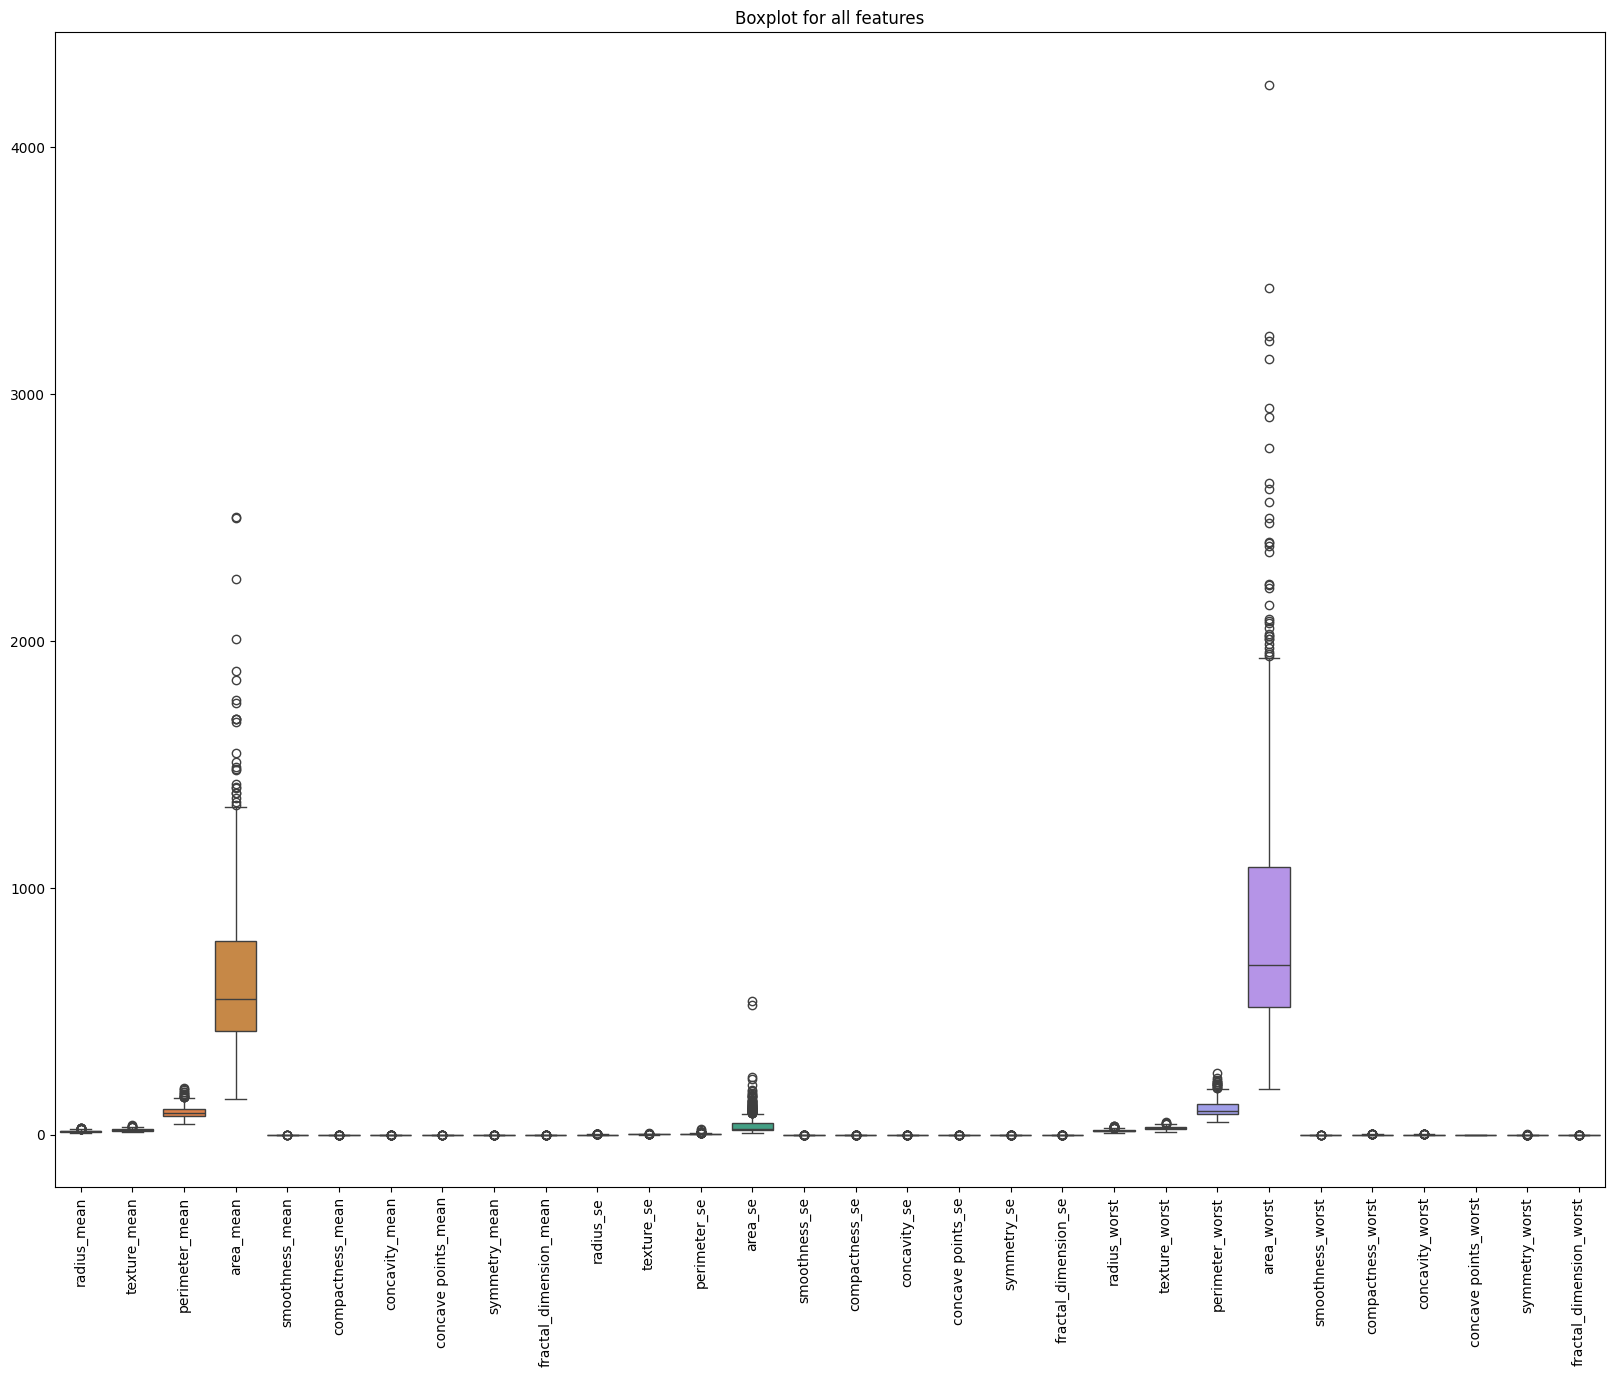

In [45]:
plt.figure(figsize=(20,15))
sns.boxplot(data=df.drop("diagnosis", axis=1))
plt.xticks(rotation=90)
plt.title("Boxplot for all features")
plt.show()

In [46]:
df['mean_radius_texture'] = df['radius_mean'] * df['texture_mean']
df['mean_area_perimeter'] = df['area_mean'] / df['perimeter_mean']


In [47]:
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]


In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [49]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [50]:
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="Accuracy",
    verbose=100
)
model.fit(X_train, y_train)


0:	learn: 0.9582418	total: 35.8ms	remaining: 17.9s
100:	learn: 1.0000000	total: 2.36s	remaining: 9.32s
200:	learn: 1.0000000	total: 4.9s	remaining: 7.28s
300:	learn: 1.0000000	total: 6.82s	remaining: 4.5s
400:	learn: 1.0000000	total: 8.62s	remaining: 2.13s
499:	learn: 1.0000000	total: 10.8s	remaining: 0us


In [51]:
y_pred = model.predict(X_test)

In [52]:
print("\n Accuracy:", accuracy_score(y_test, y_pred))
print("\n Classification Report:\n", classification_report(y_test, y_pred))


 Accuracy: 0.9649122807017544

 Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



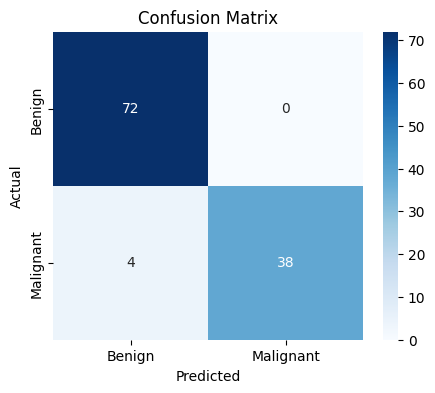

In [53]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign","Malignant"],
            yticklabels=["Benign","Malignant"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

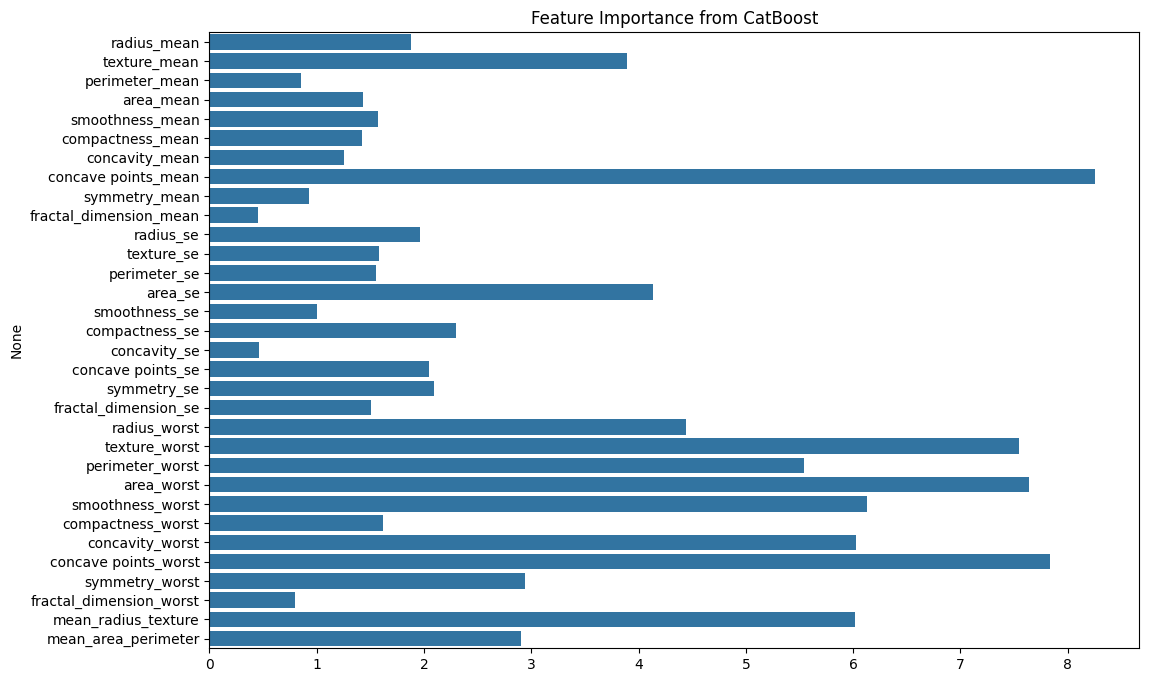

In [54]:
## Feature Importance
feature_importance = model.get_feature_importance()
features = X.columns

plt.figure(figsize=(12,8))
sns.barplot(x=feature_importance, y=features)
plt.title("Feature Importance from CatBoost")
plt.show()

In [ ]:
important_feature = features[list(feature_importance).index(max(feature_importance))]
print(" Most Important Feature:", important_feature)

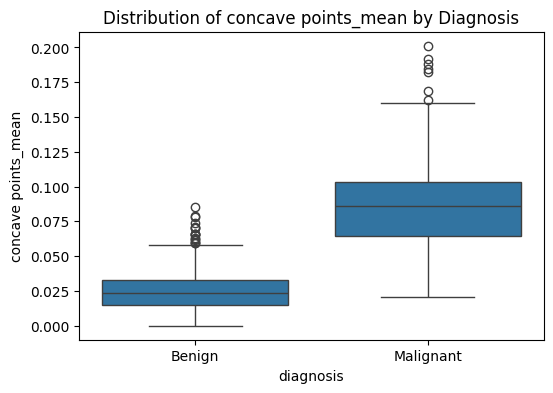

In [56]:
plt.figure(figsize=(6,4))
sns.boxplot(x="diagnosis", y=important_feature, data=df)
plt.xticks([0,1], ["Benign", "Malignant"])
plt.title(f"Distribution of {important_feature} by Diagnosis")
plt.show()

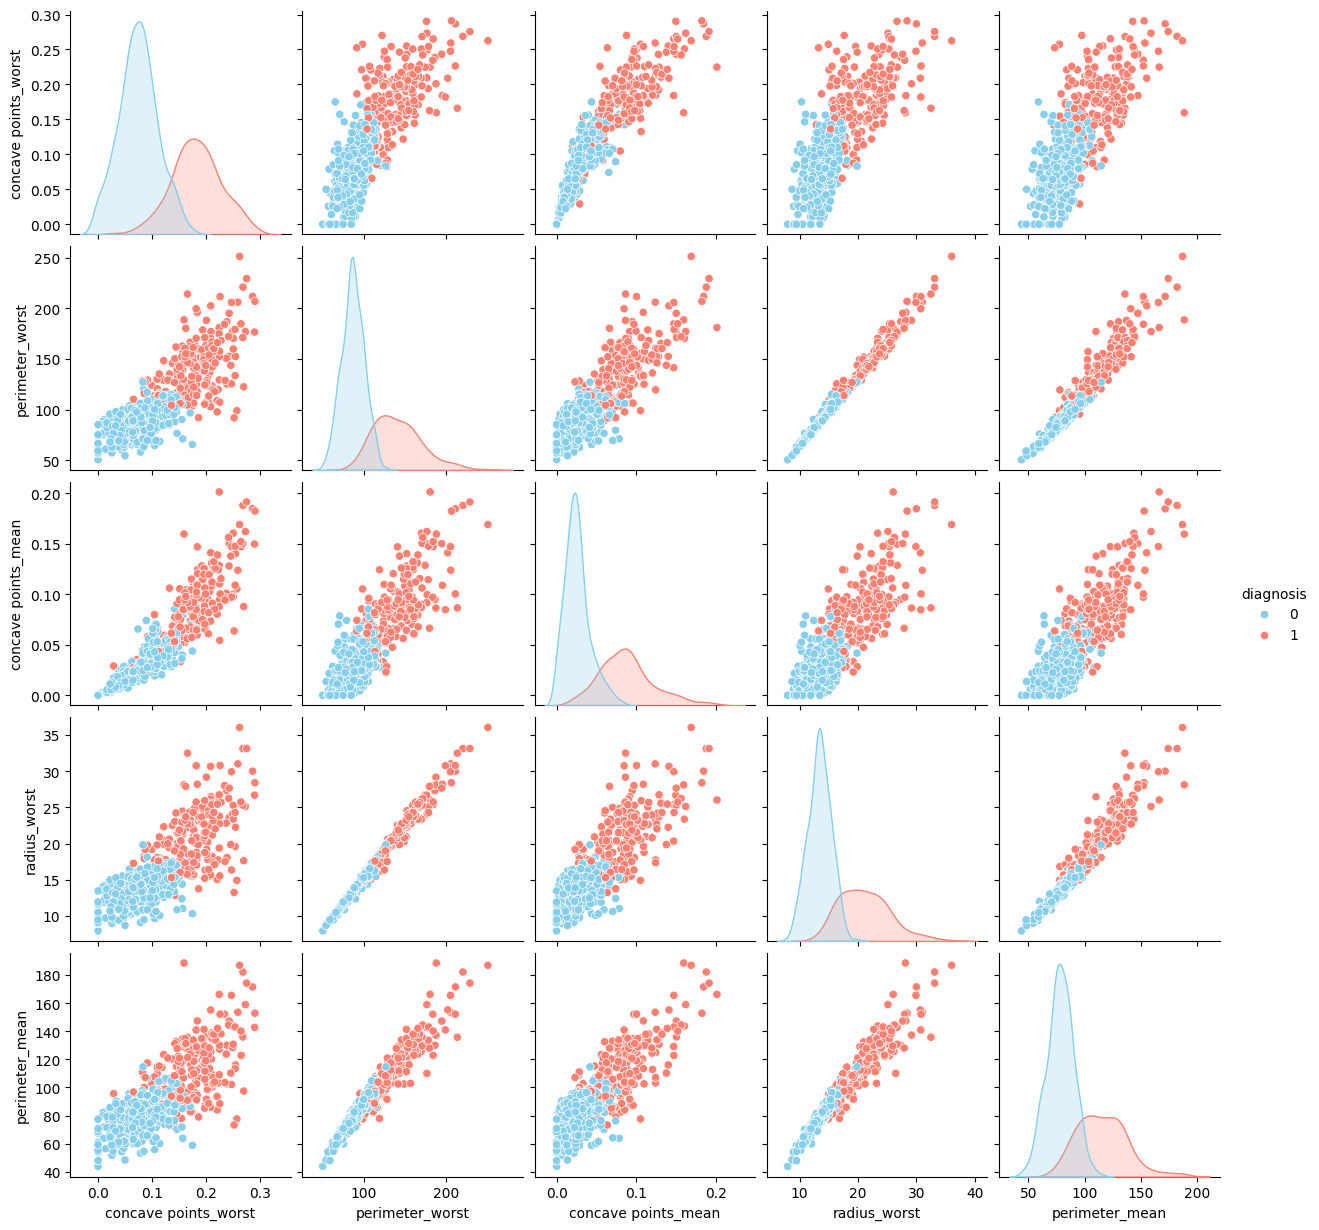

In [57]:
top_feats = corr_target[1:6].index
sns.pairplot(df, vars=top_feats, hue='diagnosis', palette=['skyblue','salmon'])
plt.show()

In [ ]:
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print("\n 5-Fold CV Accuracy Scores:", scores)
print(" Mean CV Accuracy:", scores.mean())


0:	learn: 0.9604396	total: 57ms	remaining: 28.4s
100:	learn: 1.0000000	total: 1.74s	remaining: 6.87s
200:	learn: 1.0000000	total: 3.68s	remaining: 5.47s
300:	learn: 1.0000000	total: 5.59s	remaining: 3.7s
400:	learn: 1.0000000	total: 7.5s	remaining: 1.85s
499:	learn: 1.0000000	total: 9.74s	remaining: 0us
0:	learn: 0.9736264	total: 27.9ms	remaining: 13.9s
100:	learn: 1.0000000	total: 2.13s	remaining: 8.41s
200:	learn: 1.0000000	total: 2.91s	remaining: 4.33s
300:	learn: 1.0000000	total: 3.72s	remaining: 2.46s
400:	learn: 1.0000000	total: 4.53s	remaining: 1.12s
499:	learn: 1.0000000	total: 5.34s	remaining: 0us
0:	learn: 0.9428571	total: 7.99ms	remaining: 3.99s


In [ ]:
y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()


In [ ]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

# Summary plot (bar)
shap.summary_plot(shap_values, X, plot_type="bar")